# 03. Predicting low-review orders

BQ4: can Olist spot the orders that will get a 1 or 2 star review early enough to intervene? The moment a parcel arrives, everything this model needs is known. If the risk score is high, support can reach out, apologize, or offer a voucher before the angry review lands.

Target: `is_low_review = review_score <= 2`, delivered orders only. One row per delivered order that has a delivery date and a review: 95,824 orders, 12.8% of them low reviews.

## Leakage rule

A feature is allowed only if its value exists before the customer writes the review. The review request goes out after delivery, so anything fixed at checkout, at payment, or at the moment of delivery is fair game. Anything produced by the review itself is not.

Every feature, and why it passes:

- `delivery_delay_days` (delivery date minus promised date): known the moment the parcel arrives, which is before the review exists.
- `delivery_days` (delivery date minus purchase date): same.
- `price_total`, `freight_total`, `item_count`: fixed at checkout.
- `category` (English category of the priciest item in the order): fixed at checkout.
- `payment_type` (largest payment leg), `max_installments`: fixed when the customer pays.
- `cross_state` (any item shipped from a state other than the customer's): both addresses are known at checkout.

Excluded as leakage: review text, comment title, `review_creation_date`, `review_answer_timestamp`. They do not exist until the review does. I also left out seller-level historical review averages: they would be legal if computed strictly as-of each purchase date, but one careless aggregation leaks future reviews into past predictions, and the safe version adds complexity this baseline does not need.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (average_precision_score, confusion_matrix, f1_score,
                             precision_score, recall_score, roc_auc_score)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier

P = Path("../data/processed")
FIG = Path("../reports/figures")

orders = pd.read_parquet(P / "orders.parquet")
items = pd.read_parquet(P / "order_items.parquet")
customers = pd.read_parquet(P / "customers.parquet")
reviews = pd.read_parquet(P / "reviews.parquet")
payments = pd.read_parquet(P / "payments.parquet")
products = pd.read_parquet(P / "products.parquet")
sellers = pd.read_parquet(P / "sellers.parquet")

## Feature table

Grain: one row per delivered order. Order-level rollups: item rows sum to price, freight and count; the category comes from the priciest item; the payment type from the largest leg. One delivered order has no payment row at all, so payment fields get an explicit `unknown` / 1 fill rather than a silent drop.

In [2]:
delivered = orders[
    (orders["order_status"] == "delivered") & orders["order_delivered_customer_date"].notna()
].copy()
# dates, not timestamps: arriving at 22:00 on the promised day is not late
delivered["delivery_delay_days"] = (
    delivered["order_delivered_customer_date"].dt.normalize()
    - delivered["order_estimated_delivery_date"].dt.normalize()
).dt.days
delivered["delivery_days"] = (
    delivered["order_delivered_customer_date"] - delivered["order_purchase_timestamp"]
).dt.days

item_features = items.groupby("order_id").agg(
    price_total=("price", "sum"),
    freight_total=("freight_value", "sum"),
    item_count=("order_item_id", "size"),
)

priciest = items.loc[items.groupby("order_id")["price"].idxmax(), ["order_id", "product_id"]]
priciest = priciest.merge(products[["product_id", "product_category_name_english"]], on="product_id")
priciest = priciest.set_index("order_id")["product_category_name_english"].rename("category")

seller_states = (
    items.merge(sellers[["seller_id", "seller_state"]], on="seller_id")
    .merge(delivered[["order_id", "customer_id"]], on="order_id")
    .merge(customers[["customer_id", "customer_state"]], on="customer_id")
)
cross_state = (
    (seller_states["seller_state"] != seller_states["customer_state"])
    .groupby(seller_states["order_id"]).any().astype(int).rename("cross_state")
)

main_leg = payments.loc[payments.groupby("order_id")["payment_value"].idxmax(), ["order_id", "payment_type"]]
main_leg = main_leg.set_index("order_id")["payment_type"]
max_installments = payments.groupby("order_id")["payment_installments"].max().rename("max_installments")

model_data = (
    delivered[["order_id", "delivery_delay_days", "delivery_days"]]
    .merge(reviews[["order_id", "review_score"]], on="order_id")
    .set_index("order_id")
    .join([item_features, priciest, cross_state, main_leg, max_installments])
)
model_data["category"] = model_data["category"].fillna("unknown")
model_data["payment_type"] = model_data["payment_type"].fillna("unknown")
model_data["max_installments"] = model_data["max_installments"].fillna(1)
model_data["is_low_review"] = (model_data["review_score"] <= 2).astype(int)
model_data = model_data.drop(columns="review_score")

print(f"{len(model_data):,} orders, {model_data['is_low_review'].mean():.1%} low reviews, "
      f"{model_data.isna().sum().sum()} nulls")

95,824 orders, 12.8% low reviews, 0 nulls


## Split

80/20, stratified on the target so both sets keep the 12.8% prevalence, `random_state=42` so every rerun gives identical numbers. The test set stays untouched until scoring.

In [3]:
X = model_data.drop(columns="is_low_review")
y = model_data["is_low_review"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"train {len(X_train):,} | test {len(X_test):,} | "
      f"test prevalence {y_test.mean():.3f}")

train 76,659 | test 19,165 | test prevalence 0.128


## Class imbalance

One order in eight gets a low review. Trained naively, a model reaches 87% accuracy by calling every order fine and learns nothing about the class that matters. I handle the imbalance with cost weighting, not resampling: `class_weight='balanced'` for the sklearn models and `scale_pos_weight=6.81` (the negative-to-positive ratio in the training set) for XGBoost. Both make an error on a low-review order cost roughly seven times more than an error on a happy one, which forces the model to take the minority class seriously. I chose weighting over SMOTE-style oversampling because it invents no synthetic customers, changes nothing about the data, and does the same job through the loss function; evaluation then relies on threshold-free metrics, ROC-AUC and PR-AUC, plus a decision threshold that belongs to the business, not the algorithm.

## Baseline: logistic regression

Preprocessing is one shared ColumnTransformer: scale the numeric columns, one-hot the two categoricals, and fold categories with under 500 orders into an `infrequent` bucket so 74 category levels do not become 74 near-empty columns.

In [4]:
numeric = ["delivery_delay_days", "delivery_days", "price_total", "freight_total",
           "item_count", "max_installments", "cross_state"]
categorical = ["category", "payment_type"]
# dense output: XGBoost treats zeros in a sparse matrix as missing values, so a
# sparse pipeline would silently train on different semantics than SHAP explains
preprocess = ColumnTransformer([
    ("num", StandardScaler(), numeric),
    ("cat", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=500), categorical),
], sparse_threshold=0)

def evaluate(pipe, X_test, y_test):
    proba = pipe.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)
    return {
        "precision": precision_score(y_test, pred),
        "recall": recall_score(y_test, pred),
        "f1": f1_score(y_test, pred),
        "roc_auc": roc_auc_score(y_test, proba),
        "pr_auc": average_precision_score(y_test, proba),
    }

baseline = Pipeline([
    ("prep", preprocess),
    ("model", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)),
])
baseline.fit(X_train, y_train)
results = {"logistic_regression": evaluate(baseline, X_test, y_test)}
print(pd.DataFrame(results).T.round(3).to_string())

                     precision  recall     f1  roc_auc  pr_auc
logistic_regression      0.279    0.59  0.379     0.74   0.386


The linear baseline already finds real signal: PR-AUC 0.386 against a 0.128 no-skill floor (the prevalence), triple the lift of guessing. Recall 0.59 at the default threshold, but precision 0.28 means two false alarms per real catch. Now the tree models.

## Random Forest and XGBoost

In [5]:
imbalance_ratio = (y_train == 0).sum() / (y_train == 1).sum()

models = {
    "random_forest": RandomForestClassifier(
        n_estimators=300, min_samples_leaf=5, class_weight="balanced",
        random_state=42, n_jobs=-1),
    "xgboost": XGBClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.1,
        scale_pos_weight=imbalance_ratio, tree_method="hist",
        random_state=42, n_jobs=-1),
}

fitted = {"logistic_regression": baseline}
for name, model in models.items():
    pipe = Pipeline([("prep", preprocess), ("model", model)])
    pipe.fit(X_train, y_train)
    fitted[name] = pipe
    results[name] = evaluate(pipe, X_test, y_test)

comparison = pd.DataFrame(results).T.round(3)
print(comparison.to_string())

                     precision  recall     f1  roc_auc  pr_auc
logistic_regression      0.279   0.590  0.379    0.740   0.386
random_forest            0.391   0.531  0.450    0.754   0.462
xgboost                  0.362   0.548  0.436    0.755   0.464


Both tree models beat the baseline by about 8 points of PR-AUC (0.46 vs 0.39): the extra lift comes from interactions a linear model cannot see, like delay mattering more for cheap orders. XGBoost and Random Forest tie within noise; I take XGBoost as the final model because it edges the others on both AUCs and SHAP explains it exactly.

PR-AUC is the comparison metric, not ROC-AUC. With 12.8% positives, ROC-AUC is dominated by how well the model sorts the 87% of easy negatives and flatters everyone. PR-AUC only rewards putting actual low reviews near the top of the ranking, which is the thing an outreach team would use.

## Confusion matrix, and what it costs

The 0.5 threshold is a starting point, not a law. Here is what it buys on the test set.

In [6]:
chosen = fitted["xgboost"]
proba = chosen.predict_proba(X_test)[:, 1]
pred = (proba >= 0.5).astype(int)
cm = pd.DataFrame(
    confusion_matrix(y_test, pred),
    index=["true_ok", "true_low"], columns=["pred_ok", "pred_low"],
)
print(cm.to_string())
flagged = pred.sum()
print(f"\nflags {flagged:,} of {len(y_test):,} orders ({flagged / len(y_test):.1%}), "
      f"catches {cm.loc['true_low', 'pred_low']:,} of {cm.loc['true_low'].sum():,} low reviews "
      f"({cm.loc['true_low', 'pred_low'] / cm.loc['true_low'].sum():.1%})")

          pred_ok  pred_low
true_ok     14339      2372
true_low     1108      1346

flags 3,718 of 19,165 orders (19.4%), catches 1,346 of 2,454 low reviews (54.8%)


Flagging 19.4% of orders catches 54.8% of all low reviews, and 36.2% of flagged orders are true low reviews against a 12.8% base rate, a 2.8x concentration. For the business case, recall is the metric that matters most: a missed unhappy customer costs a public 1-star review and, given the 3% repeat rate, almost certainly the customer; a false alarm costs one polite email. If the support team's capacity is smaller, raise the threshold and take the higher-precision top of the ranking first.

## What drives the predictions

Two views. Gain-based importance says how much each feature reduced the loss when trees split on it. SHAP distributes each individual prediction across features, which is the more trustworthy ranking, and the two disagree in an instructive way.

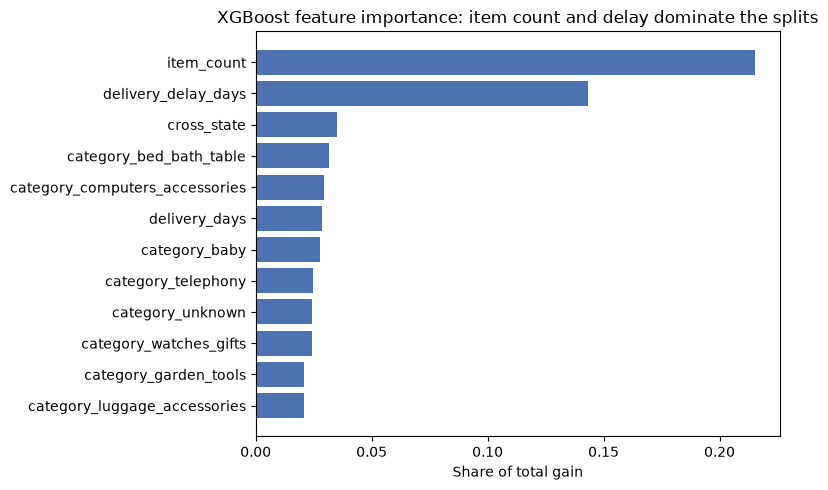

In [7]:
feature_names = [n.split("__")[1] for n in chosen["prep"].get_feature_names_out()]
gain = pd.Series(chosen["model"].feature_importances_, index=feature_names)
top_gain = gain.sort_values().tail(12)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top_gain.index, top_gain, color="#4C72B0")
ax.set_xlabel("Share of total gain")
ax.set_title("XGBoost feature importance: item count and delay dominate the splits")
fig.tight_layout()
fig.savefig(FIG / "08_model_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

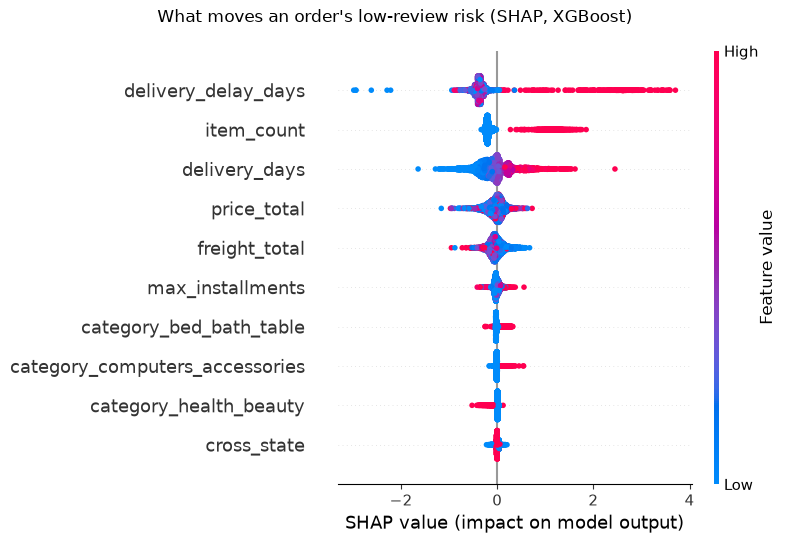

delivery_delay_days               0.484
item_count                        0.286
delivery_days                     0.268
price_total                       0.123
freight_total                     0.115
max_installments                  0.046
category_bed_bath_table           0.038
category_computers_accessories    0.023


In [8]:
X_sample = X_test.sample(5000, random_state=42)
X_transformed = chosen["prep"].transform(X_sample)
explainer = shap.TreeExplainer(chosen["model"])
shap_values = explainer.shap_values(X_transformed)

shap.summary_plot(shap_values, X_transformed, feature_names=feature_names,
                  max_display=10, show=False)
fig = plt.gcf()
fig.suptitle("What moves an order's low-review risk (SHAP, XGBoost)", fontsize=12)
fig.tight_layout()
fig.savefig(FIG / "09_shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

mean_abs = pd.Series(np.abs(shap_values).mean(axis=0), index=feature_names)
print(mean_abs.sort_values(ascending=False).head(8).round(3).to_string())

Gain ranks `item_count` first because the forest splits on it constantly, but SHAP, which measures actual contribution to each prediction, puts `delivery_delay_days` clearly on top (0.48 mean |SHAP| vs 0.29). When a splitting-frequency metric and an attribution metric disagree, trust the attribution.

In business terms: delivery delay is the single strongest driver, late arrival pushes an order hard toward a 1-2 star review, which matches the EDA where 8-to-14-days-late orders average 1.67 stars. Multi-item orders and long delivery times raise risk even when the promise is kept, consistent with split shipments and wrong-or-missing-item problems in bigger baskets. Higher freight slightly lowers risk, which looks backwards until you remember remote deliveries carry padded promises that are easier to beat, and bed_bath_table or computers_accessories items carry extra risk of their own, pointing at product quality rather than logistics.

## Wrap

An XGBoost classifier on nine pre-review features reaches PR-AUC 0.464 against a 0.128 no-skill floor, and at the default threshold turns a 12.8% base rate into a 36.2% hit-rate contact list that covers 54.8% of all coming low reviews. Delay drives it, so the same model doubles as an early-warning system: score orders daily during transit with the delay-to-date, and the riskiest ones surface before the customer is angry enough to type.